# Calendar demand and MWF delivery rhythm (CAL-01)

This notebook explores the **CAL-01** base case: calendar-shaped demand from a committed
FreshNet-derived profile, overlaid on a **Mon / Wed / Fri delivery** schedule with
**Sun / Tue / Thu** order days and lead time 1.

Prerequisites (from the repo root):

```bash
uv sync --extra dev --extra notebooks
uv run python -m ipykernel install --user --name=blueberries-voi
```

Promote any reusable logic into `src/blueberries_voi/` with tests; keep narrative here.

In [1]:
from __future__ import annotations

from datetime import date, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

from blueberries_voi.model import ModelParams, draw_demand, load_demand_profile
from blueberries_voi.rng import STREAM_DEMAND, spawn_rng
from blueberries_voi.sim.order_schedule import DEFAULT_ORDER_SCHEDULE, OrderSchedule
from blueberries_voi.voi import PHYSICS_RUN_ID

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

PROFILE_PATH = REPO_ROOT / "data" / "freshnet" / "demand_profile.json"
EPOCH = date(2024, 1, 1)  # day 0 = Monday (ASN episode clock)
N_DAYS = 90
ROOT_SEED = 42

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
schedule: OrderSchedule = DEFAULT_ORDER_SCHEDULE

## Load the committed demand profile

Runtime physics reads `data/freshnet/demand_profile.json` via `load_demand_profile` — stdlib JSON
only, no Hugging Face at draw time (ADR 0115). The mean demand on episode day `d` is

$$\mu(d) = \texttt{scale\_target\_mu} \times \texttt{dow\_factors}[d \bmod 7] \times \texttt{week\_factors}[\min(\lfloor d/7\rfloor, W-1)]$$

with `dow_index = monday0`, matching the simulation epoch.

In [2]:
profile = load_demand_profile(PROFILE_PATH)
params = ModelParams(demand_profile=profile, demand_vm=profile.demand_vm)

days = np.arange(N_DAYS)
mu = np.array([profile.mu(int(d)) for d in days])

print(f"scale_target_mu = {profile.scale_target_mu}")
print(f"demand_vm (V/M)   = {profile.demand_vm}")
print(f"dow_factors       = {[round(x, 4) for x in profile.dow_factors]}")
print(f"week_factors (n={len(profile.week_factors)}) = first/last:",
      round(profile.week_factors[0], 4), "…", round(profile.week_factors[-1], 4))
print(f"90-day mean μ     = {mu.mean():.2f} (target scale ≈ {profile.scale_target_mu})")

scale_target_mu = 30.0
demand_vm (V/M)   = 2.0
dow_factors       = [0.9708, 1.0084, 0.9288, 0.8605, 0.9254, 1.1292, 1.1769]
week_factors (n=13) = first/last: 0.835 … 1.4035
90-day mean μ     = 29.88 (target scale ≈ 30.0)


## μ(day) over 90 days — DOW and week structure

The solid line is the calendar mean μ(day). Faint bands show how **day-of-week** and
**week-index** multipliers (normalized over the Mar–Jun fit window) combine on top of
`scale_target_mu`.

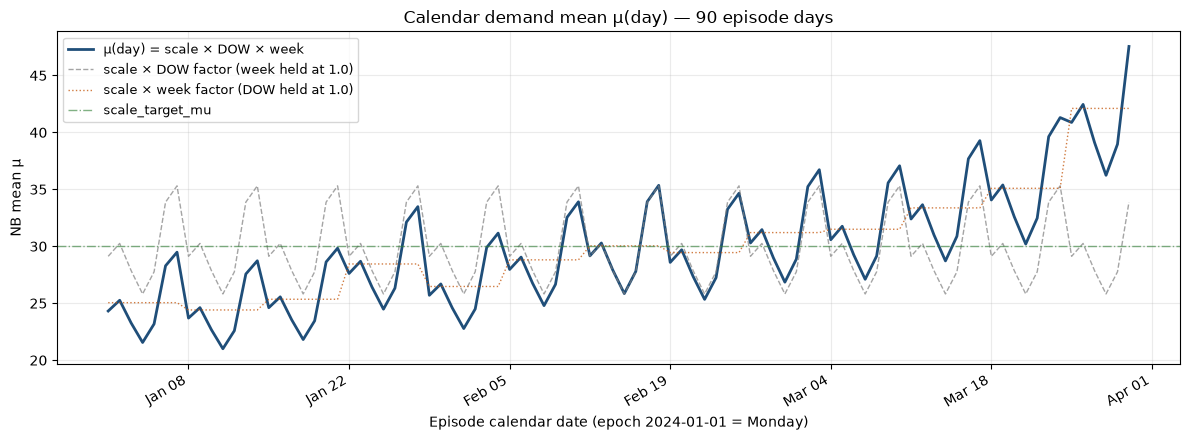

In [3]:
dow_component = np.array([profile.scale_target_mu * profile.dow_factors[int(d) % 7] for d in days])
week_idx = np.array([min(int(d) // 7, len(profile.week_factors) - 1) for d in days])
week_component = np.array([profile.scale_target_mu * profile.week_factors[w] for w in week_idx])
calendar_dates = [EPOCH + timedelta(days=int(d)) for d in days]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(calendar_dates, mu, color="#1f4e79", linewidth=2.0, label="μ(day) = scale × DOW × week")
ax.plot(
    calendar_dates,
    dow_component,
    color="#7f7f7f",
    linewidth=1.0,
    linestyle="--",
    alpha=0.7,
    label="scale × DOW factor (week held at 1.0)",
)
ax.plot(
    calendar_dates,
    week_component,
    color="#c55a11",
    linewidth=1.0,
    linestyle=":",
    alpha=0.8,
    label="scale × week factor (DOW held at 1.0)",
)
ax.axhline(profile.scale_target_mu, color="#2e7d32", linestyle="-.", linewidth=1.0, alpha=0.6, label="scale_target_mu")
ax.set_title("Calendar demand mean μ(day) — 90 episode days")
ax.set_xlabel("Episode calendar date (epoch 2024-01-01 = Monday)")
ax.set_ylabel("NB mean μ")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
fig.autofmt_xdate()
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Negative-binomial draws with hierarchical CRN

Demand randomness is addressed by **semantic slot** under a root seed (SIM-05):

```python
spawn_rng(root_seed, run_id=PHYSICS_RUN_ID, day=day, stream=STREAM_DEMAND)
```

The same `(root_seed, PHYSICS_RUN_ID, day, :demand)` tuple yields bit-identical draws across
VOI knowledge scenarios — only the filter / belief path differs. Here we overlay one CRN path
of realized demand on the deterministic μ(day) curve.

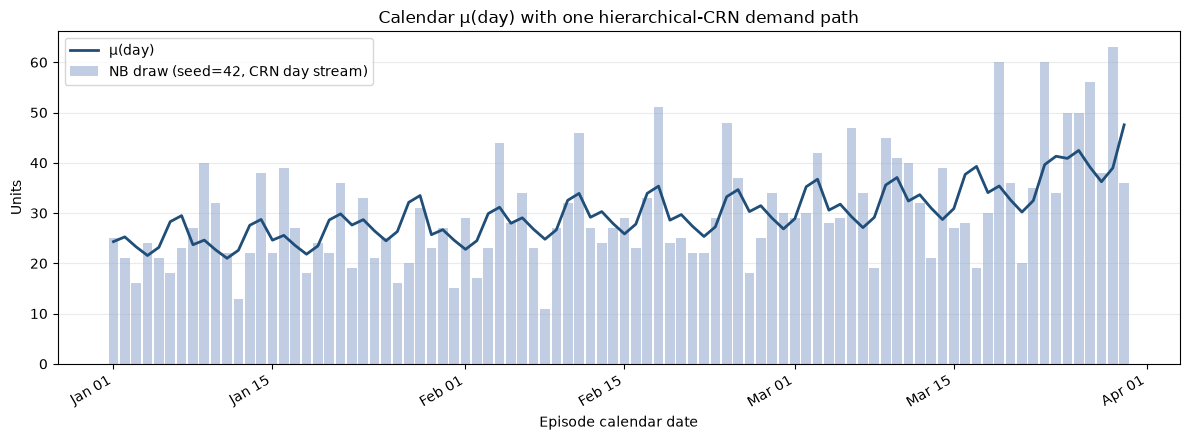

Draw mean over 90 days: 30.2  |  analytic μ mean: 29.9


In [4]:
demand_draws = []
for day in days:
    rng = spawn_rng(ROOT_SEED, run_id=PHYSICS_RUN_ID, day=int(day), stream=STREAM_DEMAND)
    demand_draws.append(draw_demand(rng, params, day=int(day)))
demand_draws = np.array(demand_draws)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(calendar_dates, mu, color="#1f4e79", linewidth=2.0, label="μ(day)")
ax.bar(
    calendar_dates,
    demand_draws,
    width=0.85,
    color="#4c72b0",
    alpha=0.35,
    label=f"NB draw (seed={ROOT_SEED}, CRN day stream)",
)
ax.set_title("Calendar μ(day) with one hierarchical-CRN demand path")
ax.set_xlabel("Episode calendar date")
ax.set_ylabel("Units")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
ax.legend(loc="upper left")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Draw mean over {N_DAYS} days: {demand_draws.mean():.1f}  |  analytic μ mean: {mu.mean():.1f}")

## Order schedule overlay — Sun / Tue / Thu orders, MWF deliveries

`OrderSchedule` (ADR 0114) locks the base-case cadence:

| Role | Weekdays (monday0) |
|------|--------------------|
| **Order** (LT = 1) | Sun (6), Tue (1), Thu (3) |
| **Deliver** | Mon (0), Wed (2), Fri (4) |

Protection length after an order day follows the **3 / 3 / 4** pattern (days until next order plus lead time).
Non-order days force `order_qty = 0`; physics still ticks daily.

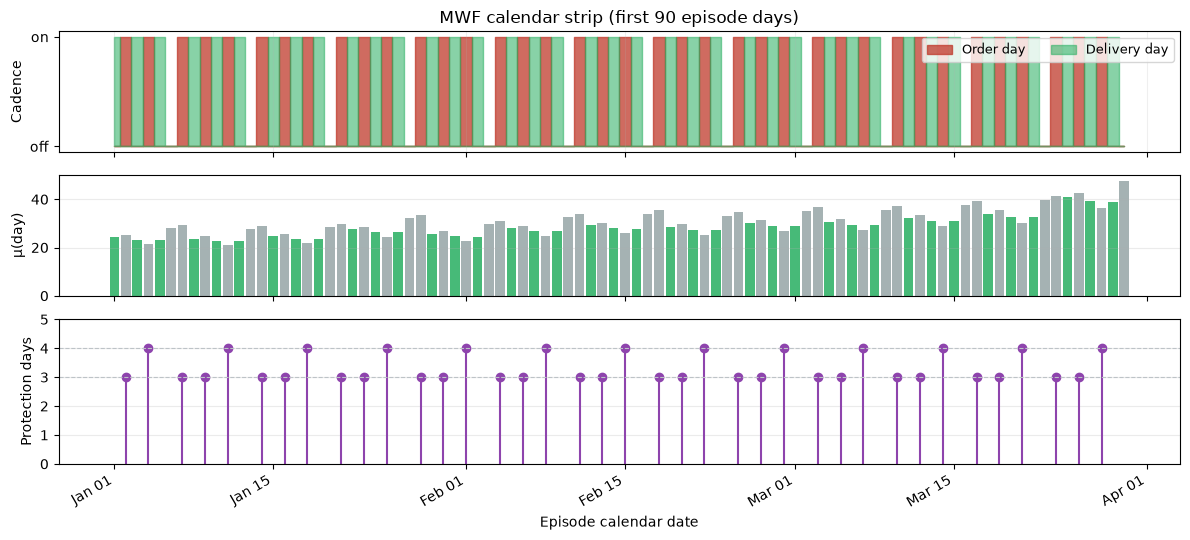

Sun (day 6): protection_days = 3
Tue (day 1): protection_days = 3
Thu (day 3): protection_days = 4


In [5]:
def weekday_label(day: int) -> str:
    return DOW_LABELS[(EPOCH + timedelta(days=day)).weekday()]


order_mask = np.array([schedule.can_order(int(d)) for d in days])
delivery_mask = np.array([(EPOCH + timedelta(days=int(d))).weekday() in schedule.delivery_weekdays for d in days])
protection = np.array([schedule.protection_days(int(d)) if schedule.can_order(int(d)) else np.nan for d in days])

fig, axes = plt.subplots(3, 1, figsize=(12, 5.5), sharex=True, gridspec_kw={"height_ratios": [1, 1, 1.2]})

# Strip 1: order vs delivery flags
ax0 = axes[0]
ax0.fill_between(calendar_dates, 0, order_mask.astype(float), step="mid", color="#c0392b", alpha=0.75, label="Order day")
ax0.fill_between(calendar_dates, 0, delivery_mask.astype(float), step="mid", color="#27ae60", alpha=0.55, label="Delivery day")
ax0.set_yticks([0, 1])
ax0.set_yticklabels(["off", "on"])
ax0.set_ylabel("Cadence")
ax0.set_title("MWF calendar strip (first 90 episode days)")
ax0.legend(loc="upper right", ncol=2, fontsize=9)
ax0.grid(True, axis="x", alpha=0.2)

# Strip 2: μ(day) colored by whether it is a delivery day
ax1 = axes[1]
colors = np.where(delivery_mask, "#27ae60", "#95a5a6")
ax1.bar(calendar_dates, mu, width=0.85, color=colors, alpha=0.85)
ax1.set_ylabel("μ(day)")
ax1.grid(True, axis="y", alpha=0.25)

# Strip 3: protection days on order days
ax2 = axes[2]
order_days = days[order_mask]
order_dates = [calendar_dates[int(d)] for d in order_days]
order_prot = [schedule.protection_days(int(d)) for d in order_days]
ax2.stem(order_dates, order_prot, linefmt="#8e44ad", markerfmt="o", basefmt=" ")
ax2.set_ylabel("Protection days")
ax2.set_xlabel("Episode calendar date")
ax2.set_ylim(0, 5)
ax2.axhline(3, color="#bdc3c7", linestyle="--", linewidth=0.8)
ax2.axhline(4, color="#bdc3c7", linestyle="--", linewidth=0.8)
ax2.grid(True, axis="y", alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Sanity: 3/3/4 on Sun / Tue / Thu in the first epoch week
for d, name in [(6, "Sun"), (1, "Tue"), (3, "Thu")]:
    print(f"{name} (day {d}): protection_days = {schedule.protection_days(d)}")

## Why periodic age under MWF ≠ stationary i.i.d. demand

The **pre–CAL-01** base case paired **daily delivery** with **i.i.d.** negative-binomial demand at a
constant μ ≈ 30. That made two convenient approximations:

1. **Demand** — each day's draw looked like the same NB(μ, V/M), so day index did not enter the
   likelihood except through inventory state.
2. **Age / replenishment** — daily arrivals produced a **stationary** cohort-age mix (modulo burn-in).

CAL-01 breaks both:

| Mechanism | Old (daily + i.i.d.) | New (MWF + calendar) |
|-----------|----------------------|----------------------|
| Arrivals | Every day | Only after Sun/Tue/Thu orders → **periodic** inter-arrival gaps (3/3/4 protection) |
| Cohort age | Approaches a daily-stationary mix | **Periodic** age distribution tied to delivery weekday |
| Demand mean | Constant μ | **μ(day)** varies with DOW × week index |
| CRN | Day slot still matters for draws | Same CRN slot, but `draw_demand(..., day=)` binds calendar μ |

Intuition: on a **delivery Monday** you inject fresh inventory; by the next **Wednesday** delivery
some cohorts have aged two tick days, while weekend demand saw **no** truck between Fri and Mon.
The joint (age, demand) process is **not** exchangeable across days — burn-in must respect the
weekly rhythm (`episode.py` defaults `n_burn` as a multiple of 7).

So: even if weekend μ is high (FreshNet DOW factors peak Sat/Sun), **you cannot** treat a 90-day
window as 90 IID pulls from one NB — nor assume the oldest-on-shelf distribution is the same every
Tuesday. Filters, controllers, and VOI cells that assumed otherwise need regeneration (changelog CAL-01).

## Honesty — FreshNet proxy, scale, and China → US transfer limits

This section records binding caveats from ADR 0115 / `data/freshnet/PROVENANCE.md`.

### SKU proxy is not blueberry-identified

FreshRetailNet-50K categories are **opaque numeric IDs** — there is no blueberry label in the hub.
The committed profile pools SKUs `{300, 117, 215, 70, 691, 191, 104, 122}` selected by
`management_group_id == 6` (largest high-velocity perishable pool). We borrow **cyclical perishable
demand shape**, not a verified blueberry series.

### `scale_target_mu = 30` is an operational knob

Fit normalizes DOW/week **factors** over the Mar–Jun 2024 window, then scales so the episode mean
μ ≈ **30** units — continuity with MOD-26 base-stock thinking. FreshNet `sale_amount` is globally
normalized Chinese retail volume, **not** punnets or USD revenue. Economics stay in scenario
`ProfitCosts`; do not import yuan pack prices.

### China → US transfer limits

- **Seasonality depth** — factors cover **Mar–Jun 2024 only**, not a full annual blueberry curve.
- **Channel mismatch** — Dingdong is front-warehouse / instant delivery; DOW spikes may reflect app
  ordering and same-day fulfillment, not Western DC→store MWF trucks.
- **Holiday calendars** — Chinese holidays in the fit window are absorbed into week factors; they are
  **not** mapped onto the US episode epoch.
- **Price / pack size** — Chinese in-season packs (~20–30 yuan / 125–250 g) do not calibrate Western
  VOI dollars; cite **shape** (DOW, censoring, stockout structure), not absolute units.

**Bottom line:** scientifically fine for perishable **demand cyclicity** and censoring awareness;
not a claim that FreshNet calibrates Western blueberry logistics or economics.

In [6]:
# Compact summary table for the blog footnote
import json

raw = json.loads(PROFILE_PATH.read_text(encoding="utf-8"))
print("Provenance snapshot")
print("-" * 40)
for key in (
    "dataset_id",
    "scale_target_mu",
    "window_start",
    "window_end",
    "sku_ids",
    "notes",
):
    print(f"{key}: {raw.get(key)!r}")

Provenance snapshot
----------------------------------------
dataset_id: 'Dingdong-Inc/FreshRetailNet-50K'
scale_target_mu: 30.0
window_start: '2024-03-28'
window_end: '2024-06-25'
sku_ids: [300, 117, 215, 70, 691, 191, 104, 122]
notes: 'mu(day) = scale_target_mu * dow_factors[dow] * week_factors[week]; factors mean-normalized over Mar-Jun window; sale_amount units are globally normalized Chinese retail - not punnets or yuan.'
